Contact : dhilip@iitrpr.ac.in <br>

    - Apoorv Kushwaha & Dr. T.J. Dhilip Kumar
        Quantum Dynamics Lab (410), IIT Ropar.

## 4D SF expansion code for 2 rigid rotors:


### ***The steps to install anaconda and libraries are given below. (Pyshtools Requires: Python >=3.6)***
1. Install anaconda from [here](https://www.anaconda.com/) 
* It is recommended to __create a new environment in anaconda to prevent any conflict__ between existing libraries and pyshtools. <br> Conflicts can take hours to resolve or may fail completely after hours of wait.
2. The library pyshtools can be installed locally using conda from this [website](https://pypi.org/project/pyshtools/). 
2. Open command prompt and enter *(One time only)*:
    1. conda create -n pysh *--creates a new clean environment pysh--*
    2. conda activate pysh *--activates the environment pysh--*
    3. conda install -c conda-forge pyshtools *--installs the pyshtools library inside pysh environment--*
    3. conda install -c conda-forge tqdm (optional, read below)
3. After installation open command prompt and enter. 
    4. conda activate pysh
    5. jupyter-notebook *--Opens jupyter notebook. Now locate the required notebook in jupyter and run--* 
* The needed __time for computing spherical harmonics term is large (several hours)__. <br> Therefore, do not run the file in google colab but preferebly run locally by installing anaconda.
4. [tqdm](https://pypi.org/project/tqdm/#installation) shows progress for any loop __(optional but useful)__


#### Importing required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
from math import sin, cos, radians
from sympy.physics.wigner import clebsch_gordan

In [2]:
import pyshtools as pysh

In [3]:
from tqdm.notebook import tqdm
import time

#### Importing input 4D PES file (E_4D_ml.csv) with descriptors as R $,\phi, \theta_2, \theta_1$ and E.

In [4]:
df_inp = pd.read_csv('4D_PES.dat',header=None,sep='\s+',names=['R','phi','th2','th1','E']) 
df_inp.sort_values(by = [ 'R','phi','th2','th1'], inplace=True, ascending = True)
df_inp.reset_index(inplace=True, drop = True)  # sorting by R, phi, th2 and th1 and reindexing

# Use below code to convert Hartree in cm^{-1}. 
#E_inf = 186.5889233299                         # Set Asymptotic (R) energy
#df_inp['E'] = (df_inp['E'] + E_inf)*219474.63  # converting to cm-1

In [5]:
df_inp[:10]  #printing df_inp to see input file. 

,R,phi,th2,th1,E
0,2.5,0,0,0,424269.734133
1,2.5,0,0,30,98040.468659
2,2.5,0,0,60,6253.008116
3,2.5,0,0,90,1281.146077
4,2.5,0,0,120,6323.170408
5,2.5,0,0,150,97282.681157
6,2.5,0,0,180,424251.254699
7,2.5,0,30,0,390680.819034
8,2.5,0,30,30,93583.895927
9,2.5,0,30,60,6155.878359


### Creating the matrix contining angular coordinates (should be same as the input angular terms) 
* This part can be avoided by also extracting angular terms from df_inp dataframe and converting to numpy. 
* The important part is to note that input energies must be sorted by R followed by $\phi, \theta_2$ and $\theta_1$. 

In [6]:
angmat = np.zeros((1,3))             # initializing matrix with zero
for i in range (0,91,30):             # loop for phi      (initial value, final value +1, step size)
    for j in range (0,91,30):         # loop for theta2   (initial, final+1, step)
        for k in range(0,181,30):     # loop for theta1   (initial, final+1, step)
            ang = np.matrix([i,j,k])
            angmat = np.append(angmat,ang,axis=0)
angmat = np.delete(angmat,0,0)       # deleting the first row (all terms in row are zero)
print("Number of angular terms: ", len(angmat))
print("Angular terms: \n", angmat)

Number of angular terms:  112
Angular terms: 
 [[  0.   0.   0.]
 [  0.   0.  30.]
 [  0.   0.  60.]
 [  0.   0.  90.]
 [  0.   0. 120.]
 [  0.   0. 150.]
 [  0.   0. 180.]
 [  0.  30.   0.]
 [  0.  30.  30.]
 [  0.  30.  60.]
 [  0.  30.  90.]
 [  0.  30. 120.]
 [  0.  30. 150.]
 [  0.  30. 180.]
 [  0.  60.   0.]
 [  0.  60.  30.]
 [  0.  60.  60.]
 [  0.  60.  90.]
 [  0.  60. 120.]
 [  0.  60. 150.]
 [  0.  60. 180.]
 [  0.  90.   0.]
 [  0.  90.  30.]
 [  0.  90.  60.]
 [  0.  90.  90.]
 [  0.  90. 120.]
 [  0.  90. 150.]
 [  0.  90. 180.]
 [ 30.   0.   0.]
 [ 30.   0.  30.]
 [ 30.   0.  60.]
 [ 30.   0.  90.]
 [ 30.   0. 120.]
 [ 30.   0. 150.]
 [ 30.   0. 180.]
 [ 30.  30.   0.]
 [ 30.  30.  30.]
 [ 30.  30.  60.]
 [ 30.  30.  90.]
 [ 30.  30. 120.]
 [ 30.  30. 150.]
 [ 30.  30. 180.]
 [ 30.  60.   0.]
 [ 30.  60.  30.]
 [ 30.  60.  60.]
 [ 30.  60.  90.]
 [ 30.  60. 120.]
 [ 30.  60. 150.]
 [ 30.  60. 180.]
 [ 30.  90.   0.]
 [ 30.  90.  30.]
 [ 30.  90.  60.]
 [ 30.  90.  90.]

### Creating the matrix contining order of radial terms $\lambda_1, \lambda_2, \& \ \lambda $
* replace step size 2 with 1 (in for loops) in case of non-symmetric molecules. 

In [7]:
Lmat = np.zeros((1,3))
L1max = 6                           # max order for radial term (NCCN)
L2max = 4                           # max order for radial term (H_2)
Symm_1 = 2                          # 1 for non symm, 2 for symm
Symm_2 = 2                          # 1 for non symm, 2 for symm
Symm = 2                            # 1 if none of the above is symm, else 2

for i in range(0,L1max+1,Symm_1):        # loop for Lambda_1 
    for j in range(0,L2max+1,Symm_1):    # loop for Lambda_2 
        for k in range(abs(i-j),abs(i+j)+1,Symm):    # loop for Lambda 
            Lc = np.matrix([i,j,k])
            Lmat = np.append(Lmat,Lc,axis=0)
Lmat = np.delete(Lmat,0,0)
Lmat = Lmat.astype(int)
print("Number of radial terms: ", len(Lmat))
#print("Radial terms: \n", Lmat) # uncomment to print all Vlam 

Number of radial terms:  28


* Adding a column with series of whole number (0-91) to identify terms in Lmat matrix.

In [8]:
num   = np.arange(len(Lmat))
num2  = np.reshape(num, (-1, 1))
Lmat1 = np.append(num2,Lmat,axis=1)
Lmat1   # Vlam along with their numbering

matrix([[ 0,  0,  0,  0],
        [ 1,  0,  2,  2],
        [ 2,  0,  4,  4],
        [ 3,  2,  0,  2],
        [ 4,  2,  2,  0],
        [ 5,  2,  2,  2],
        [ 6,  2,  2,  4],
        [ 7,  2,  4,  2],
        [ 8,  2,  4,  4],
        [ 9,  2,  4,  6],
        [10,  4,  0,  4],
        [11,  4,  2,  2],
        [12,  4,  2,  4],
        [13,  4,  2,  6],
        [14,  4,  4,  0],
        [15,  4,  4,  2],
        [16,  4,  4,  4],
        [17,  4,  4,  6],
        [18,  4,  4,  8],
        [19,  6,  0,  6],
        [20,  6,  2,  4],
        [21,  6,  2,  6],
        [22,  6,  2,  8],
        [23,  6,  4,  2],
        [24,  6,  4,  4],
        [25,  6,  4,  6],
        [26,  6,  4,  8],
        [27,  6,  4, 10]])

#### Initializing required variables
* **BiSp:** bispherical harmonics coefficient = $Y_lm(\theta_1,0) * Y_lm(\theta_2,\phi) *$ CG coefficient

In [9]:
lm = len(Lmat)               # number of lambda (radial) terms
ngm = len(angmat)            # number of angular terms
px = np.zeros((ngm,lm))      # initializing matrix to store BiSp coefficients
Rpt=77                       # number of radial (R) terms
f = np.zeros(ngm)            # 1D matrix to store energies
V_nf = np.zeros((Rpt,lm))    # 1D matrix to store least sq. fit terms

r1 = np.arange(2.5,9.0,0.1)  # creating R row with 0.1 Ang. step size
r2 = np.arange(9,21,1)       # creating R row with 1 Ang. step size
x_dummy= np. append(r1, r2, 0)    # merging two rows to create final R coordinates

## Function to calculate bispherical harmonics coefficients (using Pyshtools)

$\left (\frac{2 \lambda+1}{4 \pi}\right)^{1 / 2} \times 
[ \left\langle\lambda_{1}, 0, \lambda_{2},0 \mid \lambda, 0\right\rangle 
P_{\lambda_1}^{0}\left(\theta_1, 0\right) P_{\lambda_2}^{0} 
\sum_{m=1}^{l_m} (-1)^{m} \times 2 \times \left\langle\lambda_{1}, m, \lambda_{2},-m \mid \lambda, 0\right\rangle 
\quad P_{\lambda_1}^{m}\left(\theta_1, 0\right) P_{\lambda_2}^{-m}\left(\theta_2, \phi\right)\times cos (m\phi)]$

In [10]:
def Bispher_SF(L1,L2,L,ph,th2,th1):
    Total=0
    M_max= min(L1,L2)
    theta1 = radians(th1)
    theta2 = radians(th2)
    phi = radians(ph)
    
    U00 = np.sqrt((2*L+1)/(4*np.pi))
    T01 = clebsch_gordan(L1, L2, L, 0, 0, 0).evalf()
    P0L1 = pysh.legendre.legendre_lm (L1, 0, cos(theta1), 'unnorm', -1, 1)
    P0L2 = pysh.legendre.legendre_lm (L2, 0, cos(theta2), 'unnorm', -1, 1)
    T1 = T01*P0L1*P0L2
    Total += T1
    M=1
    while (M<=M_max):
        T02 = clebsch_gordan(L1, L2, L, M, -M, 0).evalf()
        PmL1 = pysh.legendre.legendre_lm (L1, M, cos(theta1), 'unnorm', -1, 1)
        PmL2 = pysh.legendre.legendre_lm (L2, M, cos(theta2), 'unnorm', -1, 1)
        T2 = T02*PmL1*PmL2
        Total += 2.0*pow((-1),M)*T2*(cos(M*phi))
        M+=1
    Total=Total*U00
    return Total

#### Running loop over full range of angular terms to calculate bispherical harmonics coefficients
* px stores the bispherical harmonics coefficients and C_inv stores the pseudo_inverse of the same.
* Thus V_lambda coefficients (and pseudo-inverse) are available for all combination of thetas and phi (sorted)
* The pseudo-inverse is multiplied by E values at each R point (for all angular coordinates sorted similarly)<br>
_Solving by least sq. fit will have a form given below which is more intuitive (but equivalent to pseudoinverse)_<br>
 <span style="color:red">V_n1 = np.linalg.lstsq(px3, f, rcond=None)[0]</span> <span style="color:green">_#--pseudoinverse = least sq. fit (Moore–Penrose inverse)_</span>.

In [11]:
for j2 in tqdm(range (ngm)):
    phi, th2, th1 = angmat[j2,0],angmat[j2,1],angmat[j2,2]
    for j3 in range (lm):
        L1,L2,L = Lmat[j3,0],Lmat[j3,1],Lmat[j3,2]
        pxc = Bispher_SF(L1,L2,L, phi, th2, th1) 
        px[j2,j3]=pxc   

  0%|          | 0/112 [00:00<?, ?it/s]

In [12]:
np.save("4D_BiSp_coeff.npy", px)    # save Bispherical Harmonics coefficients to numpy readable file for future use

In [13]:
px = np.load("4D_BiSp_coeff.npy")    # save Bispherical Harmonics coefficients to numpy readable file for future use

In [14]:
C_inv = np.linalg.pinv(px)

In [15]:
for i in range (Rpt):           # loop over all R 
    ct = i*ngm                  # counter
    f = df_inp.E[ct:ct+ngm]
    V_n1 = C_inv@(f)
    V_nf[i,:] = V_n1

a12 = np.arange(lm)             # a12 has same ordering as Lmat1
df_Vnf = pd.DataFrame(V_nf, columns = a12)
#df_Vnf   # prints V_lambda coefficients with Lmat1 ordering (print Lmat1 to match radial coefficient)

In [16]:
df_Vnf[15:30] # view minima region 

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
15,516.618914,48.926103,0.086447,1340.700606,45.453825,-13.803057,-23.293283,-1.948778,0.748331,0.282288,...,6.457081,591.549071,86.921707,-56.915740,51.685115,8.202577,-5.340048,4.426402,-4.086311,4.712429
16,279.695231,32.185096,0.115179,904.059934,-2.621885,11.319543,-45.772214,-1.829313,0.945261,-0.445420,...,3.067249,427.677250,49.919736,-34.067422,33.268289,3.942602,-2.604895,2.212391,-2.116046,2.562083
17,120.169093,20.166606,0.128564,595.796002,-34.779672,27.902616,-59.766891,-1.708937,1.046946,-0.894355,...,0.908935,308.060332,24.691052,-18.522897,20.814771,1.225374,-0.856910,0.792697,-0.845888,1.164227
18,15.337173,11.610657,0.131880,379.970018,-55.474867,38.348457,-67.719164,-1.590044,1.083549,-1.150402,...,-0.405004,220.917607,7.830437,-8.146815,12.536637,-0.433401,0.213378,-0.081100,-0.057729,0.285905
19,-51.164728,5.587165,0.128815,230.432471,-67.976565,44.419473,-71.416712,-1.474362,1.076663,-1.274976,...,-1.148675,157.576836,-3.124614,-1.400425,7.155825,-1.376721,0.825210,-0.585075,0.403145,-0.238343
20,-91.084800,1.410140,0.121919,128.200728,-74.678095,47.405534,-72.164285,-1.363101,1.041647,-1.311734,...,-1.514781,111.658714,-9.948749,2.820806,3.763324,-1.845813,1.132828,-0.843178,0.645748,-0.525289
21,-112.817441,-1.425856,0.112925,59.531660,-77.326731,48.247843,-70.910466,-1.257067,0.989335,-1.291495,...,-1.637630,78.474483,-13.915690,5.306083,1.716451,-2.008885,1.243829,-0.941936,0.746279,-0.656711
22,-122.326593,-3.292755,0.102994,14.506409,-77.193601,47.630577,-68.341476,-1.156759,0.927290,-1.235819,...,-1.609833,54.581131,-15.935180,6.616216,0.564057,-1.981989,1.232489,-0.941136,0.757464,-0.689335
23,-123.820145,-4.463813,0.092884,-14.007733,-75.199325,46.048682,-64.950557,-1.062443,0.860719,-1.159621,...,-1.494385,37.453074,-16.653174,7.147086,-0.007821,-1.844126,1.149403,-0.881555,0.715335,-0.662047
24,-120.241639,-5.139398,0.083067,-31.117929,-72.006873,43.857987,-61.089287,-0.974205,0.793139,-1.073068,...,-1.333383,25.239901,-16.525032,7.175888,-0.215345,-1.648142,1.028446,-0.790536,0.644115,-0.601101


In [17]:
df_Vnf.to_csv('4D_Vlam_6_4.dat', index=None, header=True,
                sep=',')    # save V_lam coefficients to file

In [18]:
# Read V_lam coefficients from file
df_Vnf = pd.read_csv('4D_Vlam_6_4.dat',sep=',',header=None)
df_Vnf.drop(0,inplace= True)
df_Vnf[15:30] # view minima region 

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
16,516.618914,48.926103,0.086447,1340.700606,45.453825,-13.803057,-23.293283,-1.948778,0.748331,0.282288,...,6.457081,591.549071,86.921707,-56.915740,51.685115,8.202577,-5.340048,4.426402,-4.086311,4.712429
17,279.695231,32.185096,0.115179,904.059934,-2.621885,11.319543,-45.772214,-1.829313,0.945261,-0.445420,...,3.067249,427.677250,49.919736,-34.067422,33.268289,3.942602,-2.604895,2.212391,-2.116046,2.562083
18,120.169093,20.166606,0.128564,595.796002,-34.779672,27.902616,-59.766891,-1.708937,1.046946,-0.894355,...,0.908935,308.060332,24.691052,-18.522897,20.814771,1.225374,-0.856910,0.792697,-0.845888,1.164227
19,15.337173,11.610657,0.131880,379.970018,-55.474867,38.348457,-67.719164,-1.590044,1.083549,-1.150402,...,-0.405004,220.917607,7.830437,-8.146815,12.536637,-0.433401,0.213378,-0.081100,-0.057729,0.285905
20,-51.164728,5.587165,0.128815,230.432471,-67.976565,44.419473,-71.416712,-1.474362,1.076663,-1.274976,...,-1.148675,157.576836,-3.124614,-1.400425,7.155825,-1.376721,0.825210,-0.585075,0.403145,-0.238343
21,-91.084800,1.410140,0.121919,128.200728,-74.678095,47.405534,-72.164285,-1.363101,1.041647,-1.311734,...,-1.514781,111.658714,-9.948749,2.820806,3.763324,-1.845813,1.132828,-0.843178,0.645748,-0.525289
22,-112.817441,-1.425856,0.112925,59.531660,-77.326731,48.247843,-70.910466,-1.257067,0.989335,-1.291495,...,-1.637630,78.474483,-13.915690,5.306083,1.716451,-2.008885,1.243829,-0.941936,0.746279,-0.656711
23,-122.326593,-3.292755,0.102994,14.506409,-77.193601,47.630577,-68.341476,-1.156759,0.927290,-1.235819,...,-1.609833,54.581131,-15.935180,6.616216,0.564057,-1.981989,1.232489,-0.941136,0.757464,-0.689335
24,-123.820145,-4.463813,0.092884,-14.007733,-75.199325,46.048682,-64.950557,-1.062443,0.860719,-1.159621,...,-1.494385,37.453074,-16.653174,7.147086,-0.007821,-1.844126,1.149403,-0.881555,0.715335,-0.662047
25,-120.241639,-5.139398,0.083067,-31.117929,-72.006873,43.857987,-61.089287,-0.974205,0.793139,-1.073068,...,-1.333383,25.239901,-16.525032,7.175888,-0.215345,-1.648142,1.028446,-0.790536,0.644115,-0.601101


## Below is the basic (template) code to fit the multipole expansion terms into MOLSCAT readable functions. 

* The function given below is a sum of three Slater functions of increasing order where coefficients a, b and c are optimised based on the data.
* Use as template - A good fit will require tweaking in order and number of functions. 
    * Too many functions will overfit the data and behave poorly with high energy region 
    * Less functions will underfit the data and give poor description of minima. 

In [19]:
from scipy.optimize import curve_fit

a,b,c,d,e,f,rmsx = np.zeros(lm),np.zeros(lm),np.zeros(lm),np.zeros(lm),np.zeros(lm),np.zeros(lm),np.zeros(lm)
def exp_fit(x, a,b,c):
    return  a*np.exp(-1*x)+b*np.exp(-2*x)+c*np.exp(-3*x)

Radial coefficient [l1 l2 l]:  [[0 0 0]]
Fitting coefficients for exp_fit function [a b c]:  [-1.03763896e+04 -2.74914099e+06  2.65111797e+08]


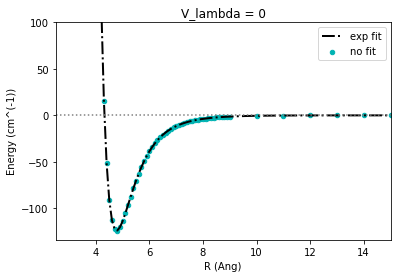

Double exponential RMSE =  2.236829403419459e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[0 2 2]]
Fitting coefficients for exp_fit function [a b c]:  [-1.36250655e+03  1.25783833e+03  1.19558568e+07]


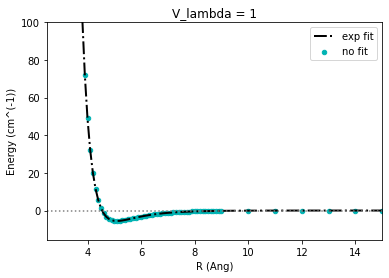

Double exponential RMSE =  1.7137649417632206e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[0 4 4]]
Fitting coefficients for exp_fit function [a b c]:  [ 5.29028230e+00  1.34849171e+03 -7.53255658e+04]


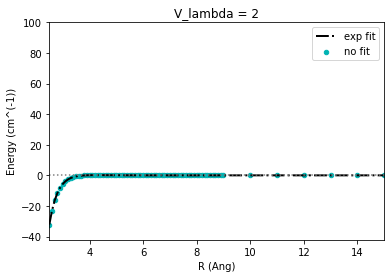

Double exponential RMSE =  1.62410965347856e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[2 0 2]]
Fitting coefficients for exp_fit function [a b c]:  [-3.68693769e+03 -2.98734675e+06  3.92299660e+08]


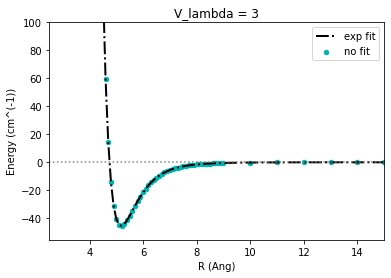

Double exponential RMSE =  6.20661203111946e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[2 2 0]]
Fitting coefficients for exp_fit function [a b c]:  [-1.20675857e+04 -1.62509538e+03  4.34595210e+07]


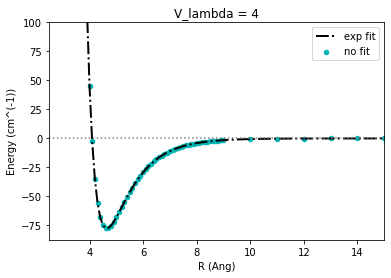

Double exponential RMSE =  7.803546066519913e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[2 2 2]]
Fitting coefficients for exp_fit function [a b c]:  [ 7.25721642e+03 -9.81084095e+03 -2.33443172e+07]


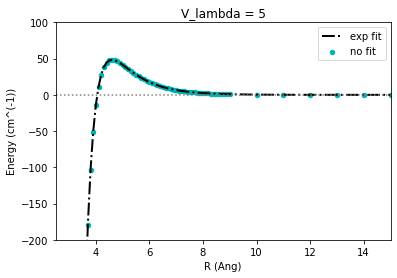

Double exponential RMSE =  3.617334334560451e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[2 2 4]]
Fitting coefficients for exp_fit function [a b c]:  [-9.70707673e+03  2.46803291e+04  2.37977941e+07]


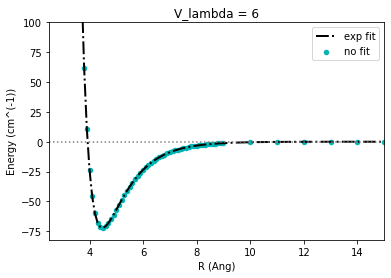

Double exponential RMSE =  4.9578459059394254e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[2 4 2]]
Fitting coefficients for exp_fit function [a b c]:  [-147.00627533 2142.62146174 4063.36476412]


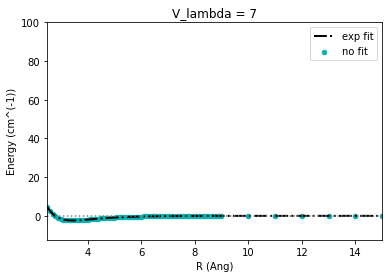

Double exponential RMSE =  5.418003738663127e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[2 4 4]]
Fitting coefficients for exp_fit function [a b c]:  [ 1.03030110e+02  3.11320637e+03 -3.55309215e+05]


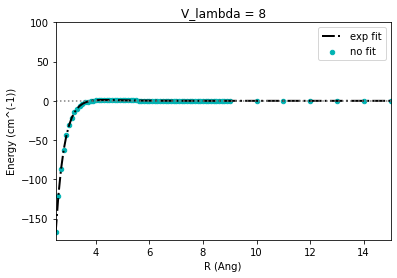

Double exponential RMSE =  3.998757833571855e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[2 4 6]]
Fitting coefficients for exp_fit function [a b c]:  [-1.10114293e+02 -1.23867091e+04  1.05048123e+06]


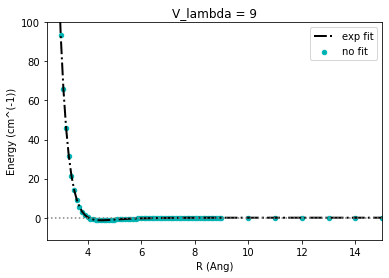

Double exponential RMSE =  4.988108522818542e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[4 0 4]]
Fitting coefficients for exp_fit function [a b c]:  [-1.08605888e+02 -1.42384418e+06  2.82655620e+08]


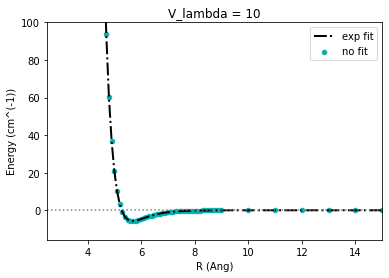

Double exponential RMSE =  7.83747920078359e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[4 2 2]]
Fitting coefficients for exp_fit function [a b c]:  [-1.83891880e+03 -4.33164956e+05  4.69692075e+07]


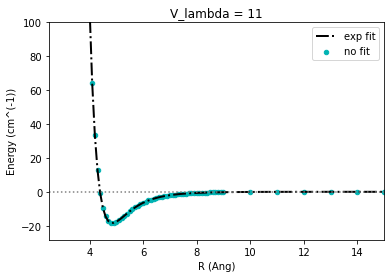

Double exponential RMSE =  9.721297106832791e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[4 2 4]]
Fitting coefficients for exp_fit function [a b c]:  [ 1.97231544e+03  3.07627255e+05 -3.51965689e+07]


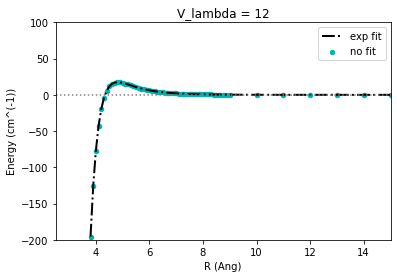

Double exponential RMSE =  7.63089024446304e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[4 2 6]]
Fitting coefficients for exp_fit function [a b c]:  [-3.37593937e+03 -3.43881364e+05  4.19772414e+07]


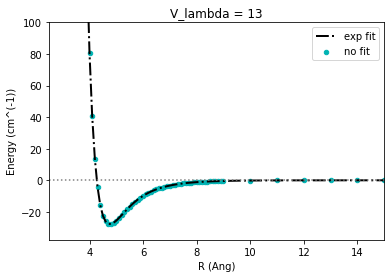

Double exponential RMSE =  8.900337446263506e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[4 4 0]]
Fitting coefficients for exp_fit function [a b c]:  [ 2.52216421e+02 -1.30742375e+05  7.99336930e+06]


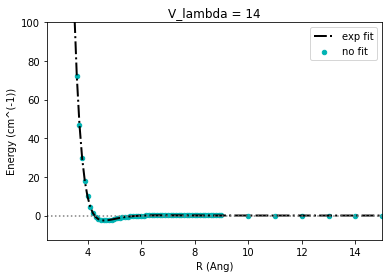

Double exponential RMSE =  1.848967410090259e-13
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[4 4 2]]
Fitting coefficients for exp_fit function [a b c]:  [-1.32819694e+02  6.89344745e+04 -4.21646929e+06]


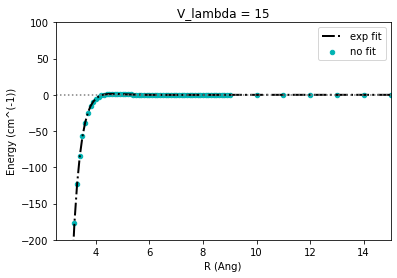

Double exponential RMSE =  9.322292632039237e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[4 4 4]]
Fitting coefficients for exp_fit function [a b c]:  [ 1.12908518e+02 -5.87187040e+04  3.59487631e+06]


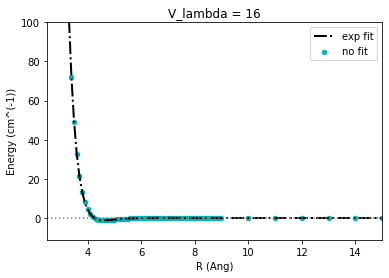

Double exponential RMSE =  7.945712596163074e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[4 4 6]]
Fitting coefficients for exp_fit function [a b c]:  [-1.17183535e+02  6.10420680e+04 -3.74126770e+06]


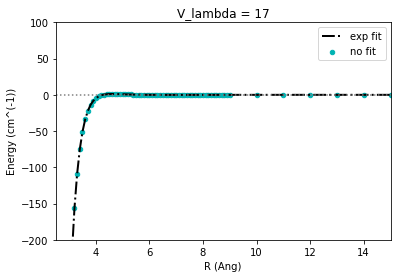

Double exponential RMSE =  8.043073338321576e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[4 4 8]]
Fitting coefficients for exp_fit function [a b c]:  [ 1.61701085e+02 -8.42508735e+04  5.16883855e+06]


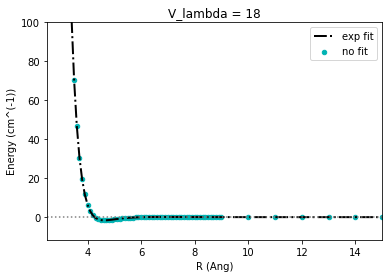

Double exponential RMSE =  1.1019932735654078e-13
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[6 0 6]]
Fitting coefficients for exp_fit function [a b c]:  [-5.05017879e+02 -3.45718215e+05  1.16658458e+08]


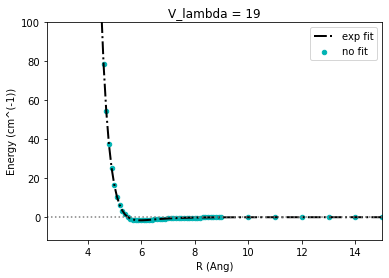

Double exponential RMSE =  3.811106846005022e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[6 2 4]]
Fitting coefficients for exp_fit function [a b c]:  [-1.70306869e+03 -3.58010638e+05  3.87704191e+07]


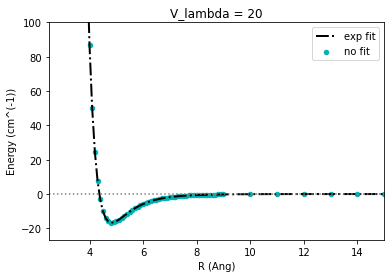

Double exponential RMSE =  8.041991180980924e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[6 2 6]]
Fitting coefficients for exp_fit function [a b c]:  [ 3.31597368e+02  2.71672628e+05 -2.50846101e+07]


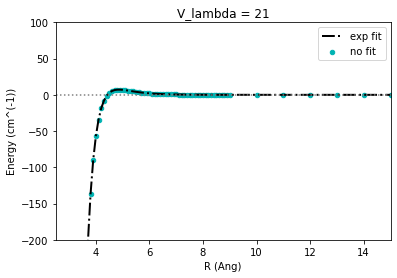

Double exponential RMSE =  5.6760658808311606e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[6 2 8]]
Fitting coefficients for exp_fit function [a b c]:  [ 1.08186697e+03 -3.16452598e+05  2.24647266e+07]


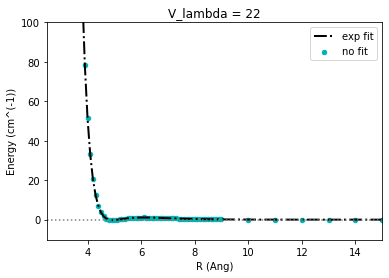

Double exponential RMSE =  4.935123849072065e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[6 4 2]]
Fitting coefficients for exp_fit function [a b c]:  [ 2.00280142e+02 -1.04668031e+05  6.45266290e+06]


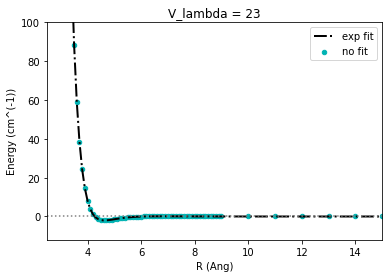

Double exponential RMSE =  1.4341914047756848e-13
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[6 4 4]]
Fitting coefficients for exp_fit function [a b c]:  [-1.28931728e+02  6.65130952e+04 -4.11627034e+06]


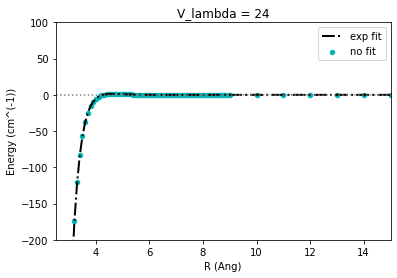

Double exponential RMSE =  9.020874882128886e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[6 4 6]]
Fitting coefficients for exp_fit function [a b c]:  [ 1.04818245e+02 -5.28625563e+04  3.29415715e+06]


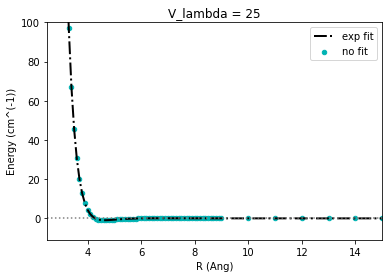

Double exponential RMSE =  6.39918443043248e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[6 4 8]]
Fitting coefficients for exp_fit function [a b c]:  [-9.38756837e+01  4.56514918e+04 -2.87771427e+06]


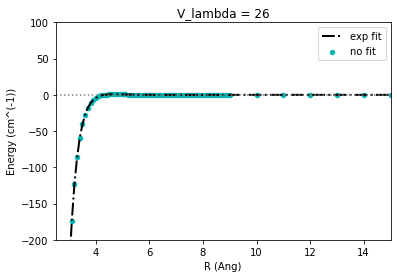

Double exponential RMSE =  5.4507404994975587e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[ 6  4 10]]
Fitting coefficients for exp_fit function [a b c]:  [ 1.03470729e+02 -4.74354422e+04  3.04841582e+06]


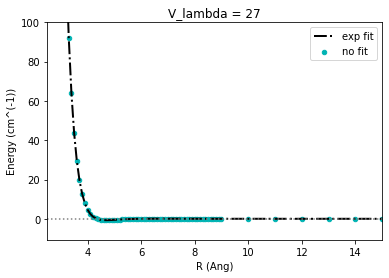

Double exponential RMSE =  4.724199918721506e-14
----------------------------------------------------------------------------------------------------


Average fit RMSE =  6.924171548882284e-14


In [20]:
strt=15     # starting point for fit (choose carefully)
for i in range(0,lm):
    j=int(i)
    y_dummy = df_Vnf[j]
    parsx, covx = curve_fit(f=exp_fit, xdata=x_dummy[strt:], ydata=y_dummy[strt:], p0=[0,0,1000])
    a[j],b[j],c[j] = parsx
    print("Radial coefficient [l1 l2 l]: ", Lmat[i])
    print("Fitting coefficients for exp_fit function [a b c]: ",parsx)
    
    # Plot the fit data as an overlay on the scatter data
    plt.scatter(x_dummy, y_dummy,s=20, color='#00b3b3',label = 'no fit')
    
    # new range for fitted curve
    xdummy=np.arange(2.5,15.1,0.1)
    plt.plot(xdummy, exp_fit(xdummy, *parsx), linestyle='-.', linewidth=2, color='black', label = 'exp fit')
    plt.legend(loc="upper right")
    plt.ylabel("Energy (cm^(-1))")
    plt.xlabel("R (Ang)")
    plt.axhline(y=0, color='grey', linestyle=':')
    plt.title("V_lambda = %d" %(i))
    plt.ylim(max(y_dummy.min()-10,-200), 100)
    plt.xlim(2.5, 15)
    plt.show()
    print('Double exponential RMSE = ',np.sqrt(np.average(np.power((exp_fit(x_dummy[strt:], 
                                                                            *parsx) - y_dummy[strt:]),2))))
    print('-----'*20)
    print('\n')
    rmsx[j]=np.sqrt(np.average(np.power((exp_fit(x_dummy[strt:], *parsx) - y_dummy[strt:]),2)))
print('Average fit RMSE = ',np.average(rmsx))

In [21]:
# save output for each V lambdas as required by molscat!
print('LAMBDA ='),
for j in range (lm):
    print(Lmat[j,0],',',Lmat[j,1],',',Lmat[j,2],',')
print('NTERM  = ', '3,'*lm)
print('NPOWER = ', '0,0,0'*int(lm))
print('A      = ')
for j in range (lm):
    print(a[j],',',b[j],',',c[j],',')
print('E      =', '-1,-2,-3,'*lm) # change as per funtion taken above

LAMBDA =
0 , 0 , 0 ,
0 , 2 , 2 ,
0 , 4 , 4 ,
2 , 0 , 2 ,
2 , 2 , 0 ,
2 , 2 , 2 ,
2 , 2 , 4 ,
2 , 4 , 2 ,
2 , 4 , 4 ,
2 , 4 , 6 ,
4 , 0 , 4 ,
4 , 2 , 2 ,
4 , 2 , 4 ,
4 , 2 , 6 ,
4 , 4 , 0 ,
4 , 4 , 2 ,
4 , 4 , 4 ,
4 , 4 , 6 ,
4 , 4 , 8 ,
6 , 0 , 6 ,
6 , 2 , 4 ,
6 , 2 , 6 ,
6 , 2 , 8 ,
6 , 4 , 2 ,
6 , 4 , 4 ,
6 , 4 , 6 ,
6 , 4 , 8 ,
6 , 4 , 10 ,
NTERM  =  3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,
NPOWER =  0,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,0
A      = 
-10376.38958983445 , -2749140.994453183 , 265111797.49282643 ,
-1362.5065476270881 , 1257.838334770413 , 11955856.774761695 ,
5.290282298083685 , 1348.4917105331983 , -75325.56576345311 ,
-3686.9376903420907 , -2987346.747791105 , 392299659.8506054 ,
-12067.58568339515 , -1625.095378700005 , 43459520.96227488 ,
7257.2164176227625 , -9810.840952497092 , -23344317.181888532 ,
-9707.076729389297 , 24680.329105960907 , 2379779

## For more functions/options to fit radial coefficients, see: 
### CODE_4_MP_fit.ipynb
    The jupyter-notebook contains 3 common functions and fits 2D radial coefficients.